**Market Basket Analysis & Association Rules Mining Voting Patterns**
-
* **Name/s:** Enrico Miguel Veloso, John Dennis Vergara, Shane Hans Uy
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 5/9/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
---
* **Implementation of models and concepts:** Market Basket Analysis & Association Rules
* **Dataset:** 2022 Philippine National and Local Elections; Precinct-level results (Figshare, CC BY 4.0)
* **Description:** In this laboratory, you will apply Market Basket Analysis (MBA) to real-world election data from the 2022 Philippine Senatorial Elections. Instead of grocery items in a shopping cart, each province is treated as a transaction and the senatorial candidates who topped the vote in that province are treated as items.
* **Objective:** Your goal is to discover which senators are consistently voted together across provinces; revealing regional political bloc patterns hidden in the data.
---

_**Import all necessary Python Libraries.**_

In [226]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
import matplotlib.pyplot as plt

**1. Data Loading & Aggregation Load**
---

_**T1.1 - Load sen.csv into a pandas DataFrame. Print the shape and first 3 rows.**_

In [227]:
#Kindly change the file location where your dataset is located:
df = pd.read_csv("C:/Users/Marian Veloso/Documents/Coding Files/PyCharm Codes/sen.csv", encoding='utf-8') 

In [228]:
print("Shape of raw data:", df.shape)
print("=" * 31)
print("First 3 rows:")
print("=" * 72)
print(df.head(3))

Shape of raw data: (105971, 71)
First 3 rows:
   Unnamed: 0 region province   city      brgy  precinct  total_votes  \
0           0  BARMM  BASILAN  AKBAR  CADDAYAN   7080005         1320   
1           1  BARMM  BASILAN  AKBAR  LINONGAN   7080001          968   
2           2  BARMM  BASILAN  AKBAR  LINONGAN   7080002          513   

   sen_1_afuang  sen_2_albani  sen_3_arranza  ...  sen_55_sahidulla  \
0             2            32              0  ...                10   
1             0            14              0  ...                 8   
2             0             9              0  ...                 2   

   sen_56_sison  sen_57_teodoro  sen_58_trillanes  sen_59_tulfo  \
0             3              28                 7            53   
1             0              61                 0            34   
2             0               8                 0            12   

   sen_60_valeros  sen_61_villanueva  sen_62_villar  sen_63_zubiaga  \
0               1                 51

_**T1.2 - Extract only the senator vote columns (columns starting with sen_). Sum the votes per province using groupby('province').**_

In [229]:
senator_cols = [col for col in df.columns if col.startswith('sen_')]
province_votes = df.groupby('province')[senator_cols].sum()

_**T1.3 - For each province, identify the Top 8 senators by total votes. Store the result as a list of lists each inner list is one province's top senators using last names only (e.g., ['padilla', 'tulfo', 'legarda', ...]).**_

In [230]:
transactions = []
for province, row in province_votes.iterrows():
    sorted_senators = row.sort_values(ascending=False).index
    top_senators = [col.split('_')[-1] for col in sorted_senators[:8]]
    transactions.append(top_senators)

In [231]:
print("Transactions (one per province, top 8 senators):")
print("=" * 48)
print(transactions)

Transactions (one per province, top 8 senators):
[['padilla', 'estrada', 'villar', 'binay', 'tulfo', 'ejercito', 'legarda', 'gatchalian'], ['padilla', 'zubiri', 'legarda', 'villar', 'gatchalian', 'villanueva', 'teodoro', 'tulfo'], ['padilla', 'zubiri', 'legarda', 'cayetano', 'villar', 'gatchalian', 'ejercito', 'tulfo'], ['legarda', 'tulfo', 'hontiveros', 'villanueva', 'escudero', 'padilla', 'gatchalian', 'villar'], ['escudero', 'hontiveros', 'tulfo', 'trillanes', 'lima', 'legarda', 'cayetano', 'diokno'], ['legarda', 'padilla', 'escudero', 'villar', 'tulfo', 'zubiri', 'bautista', 'teodoro'], ['legarda', 'tulfo', 'padilla', 'escudero', 'gatchalian', 'cayetano', 'hontiveros', 'villanueva'], ['padilla', 'tulfo', 'legarda', 'villar', 'binay', 'estrada', 'ejercito', 'cayetano'], ['padilla', 'legarda', 'villar', 'gadon', 'roque', 'bautista', 'teodoro', 'tulfo'], ['padilla', 'tulfo', 'legarda', 'villanueva', 'gatchalian', 'escudero', 'cayetano', 'villar'], ['padilla', 'tulfo', 'legarda', 'zubi

_**T1.4 - Print the transaction list. Verify you have one transaction per province (~90 transactions).**_

In [232]:
print(f"Number of transactions (provinces): {len(transactions)}")

Number of transactions (provinces): 90


**2. Frequent Itemset Mining Apply the Apriori Algorithm**
-

_**T2.1 - Use TransactionEncoder from mlxtend to convert the list of lists into a one-hot encoded DataFrame.**_

In [233]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

_**T2.2 - Apply apriori() with min_support=0.3. Print the number of frequent itemsets found.**_

In [234]:
freq_itemsets = apriori(df_encoded, min_support=0.3, use_colnames=True)

In [235]:
print(f"Number of frequent itemsets (min_support=0.3): {len(freq_itemsets)}")

Number of frequent itemsets (min_support=0.3): 191


_**T2.3 - Add an itemset_size column and display 2-itemsets and 3-itemsets separately.**_

In [236]:
freq_itemsets['itemset_size'] = freq_itemsets['itemsets'].apply(len)
two_itemsets = freq_itemsets[freq_itemsets['itemset_size'] == 2]
three_itemsets = freq_itemsets[freq_itemsets['itemset_size'] == 3]

In [237]:
print("2-itemsets:")
print("=" * 52)
print(two_itemsets)

2-itemsets:
     support                  itemsets  itemset_size
10  0.411111      (cayetano, escudero)             2
11  0.577778    (cayetano, gatchalian)             2
12  0.711111       (cayetano, legarda)             2
13  0.666667       (cayetano, padilla)             2
14  0.677778         (cayetano, tulfo)             2
15  0.311111    (cayetano, villanueva)             2
16  0.522222        (cayetano, villar)             2
17  0.344444        (cayetano, zubiri)             2
18  0.466667    (escudero, gatchalian)             2
19  0.555556       (escudero, legarda)             2
20  0.488889       (padilla, escudero)             2
21  0.555556         (escudero, tulfo)             2
22  0.377778    (villanueva, escudero)             2
23  0.355556        (escudero, villar)             2
24  0.377778        (legarda, estrada)             2
25  0.377778        (padilla, estrada)             2
26  0.344444          (estrada, tulfo)             2
27  0.322222         (villar, estr

In [238]:
print("3-itemsets:")
print("=" * 61)
print(three_itemsets)

3-itemsets:
      support                          itemsets  itemset_size
48   0.366667  (cayetano, escudero, gatchalian)             3
49   0.411111     (cayetano, escudero, legarda)             3
50   0.355556     (cayetano, padilla, escudero)             3
51   0.411111       (cayetano, escudero, tulfo)             3
52   0.566667   (cayetano, gatchalian, legarda)             3
..        ...                               ...           ...
107  0.366667          (padilla, zubiri, tulfo)             3
108  0.300000     (villanueva, padilla, villar)             3
109  0.366667         (padilla, villar, zubiri)             3
110  0.311111       (villanueva, villar, tulfo)             3
111  0.344444           (villar, zubiri, tulfo)             3

[64 rows x 3 columns]


_**T2.4 - Which 2-senator pair has the highest support? What does this tell you politically?**_

In [239]:
if not two_itemsets.empty:
    top_pair = two_itemsets.loc[two_itemsets['support'].idxmax()]
    top_trio = three_itemsets.loc[three_itemsets['support'].idxmax()]
    print(f"1.) 2-senator pair with highest support: {top_pair['itemsets']} (support={top_pair['support']:.3f})")
    print(f"2.) 3-senator trio with highest support: {top_trio['itemsets']} (support={top_trio['support']:.3f})")
    print("3.) Interpretation: This pair of senators tend to win together across many provinces, suggesting a strong voting block.")
else:
    print("No 2-itemsets found with min_support=0.3.")

1.) 2-senator pair with highest support: frozenset({'legarda', 'tulfo'}) (support=0.933)
2.) 3-senator trio with highest support: frozenset({'padilla', 'legarda', 'tulfo'}) (support=0.867)
3.) Interpretation: This pair of senators tend to win together across many provinces, suggesting a strong voting block.


**3. Association Rule Generation Generate and Filter Association Rules**
-

_**T3.1 - Use association_rules() with metric='confidence' and min_threshold=0.7. Remember to pass num_itemsets=len(frequent_itemsets) to avoid version errors.**_

In [240]:
freq_itemsets['itemsets'] = freq_itemsets['itemsets'].apply(lambda x: frozenset(str(i) for i in x))
rules = association_rules(freq_itemsets, metric='confidence', min_threshold=0.7, num_itemsets=len(freq_itemsets))

_**T3.2 - Display all rules sorted by lift (descending). Keep only columns: antecedents, consequents, support, confidence, lift.**_

In [241]:
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_sorted = rules.sort_values('lift', ascending=False)

In [242]:
print("Association rules sorted by lift:")
print("=" * 76)
print(rules_sorted)

Association rules sorted by lift:
                               antecedents                    consequents  \
944  (villanueva, padilla, legarda, tulfo)         (escudero, gatchalian)   
734         (villanueva, padilla, legarda)         (escudero, gatchalian)   
953         (villanueva, padilla, legarda)  (escudero, gatchalian, tulfo)   
737      (villanueva, gatchalian, legarda)            (padilla, escudero)   
957      (villanueva, gatchalian, legarda)     (padilla, escudero, tulfo)   
..                                     ...                            ...   
139                    (padilla, escudero)                       (villar)   
462             (padilla, escudero, tulfo)                       (villar)   
440           (padilla, escudero, legarda)                       (villar)   
48                            (villanueva)                       (villar)   
257                    (villanueva, tulfo)                       (villar)   

      support  confidence      lift  
944

_**T3.3 - Filter to rules where lift > 1.2 AND confidence > 0.75. How many rules remain?.**_

In [243]:
filtered_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.75)]

In [244]:
print(f"Number of rules with lift>1.2 and confidence>0.75: {len(filtered_rules)}")

Number of rules with lift>1.2 and confidence>0.75: 82


_**T3.4 - Identify the rule with the highest lift. Write one sentence interpreting what this rule means in the context of the 2022 elections.**_

In [245]:
if not filtered_rules.empty:
    best_rule = filtered_rules.loc[filtered_rules['lift'].idxmax()]
    print(f"1.) Lift = {best_rule['lift']:.3f}, Confidence = {best_rule['confidence']:.3f}")
    print(f"2.) Rule with highest lift: {best_rule['antecedents']} -> {best_rule['consequents']}")
    print("3.) Interpretation: This rule indicates that if a province votes for the antecedent senator(s), it is highly likely to also vote for the consequent senator.")
else:
    print("No rules satisfied the filter criteria.")

1.) Lift = 1.714, Confidence = 0.800
2.) Rule with highest lift: frozenset({'villanueva', 'padilla', 'legarda'}) -> frozenset({'escudero', 'gatchalian'})
3.) Interpretation: This rule indicates that if a province votes for the antecedent senator(s), it is highly likely to also vote for the consequent senator.


**4. Lift Heatmap Senator-to-Senator Association Strength using a Lift Heatmap**
-

_**T4.1 - Filter rules to single antecedent → single consequent only.**_

In [246]:
single_rules = rules[(rules['antecedents'].apply(len) == 1) & (rules['consequents'].apply(len) == 1)].copy()
single_rules['ant_str'] = single_rules['antecedents'].apply(lambda x: list(x)[0])
single_rules['con_str'] = single_rules['consequents'].apply(lambda x: list(x)[0])

_**T4.2 - Build a square lift matrix manually: create a DataFrame filled with 1.0 as the baseline, then populate it with lift values from the filtered rules.**_

In [247]:
items = sorted(set(single_rules['ant_str']) | set(single_rules['con_str']))
lift_matrix = pd.DataFrame(1.0, index=items, columns=items)
for _, row in single_rules.iterrows():
    lift_matrix.loc[row['ant_str'], row['con_str']] = row['lift']

_**T4.3 - Plot the heatmap using seaborn with cmap='RdYlGn', center=1.0, and annotated values. Add a title, axis labels, and rotate x-axis tick labels.**_

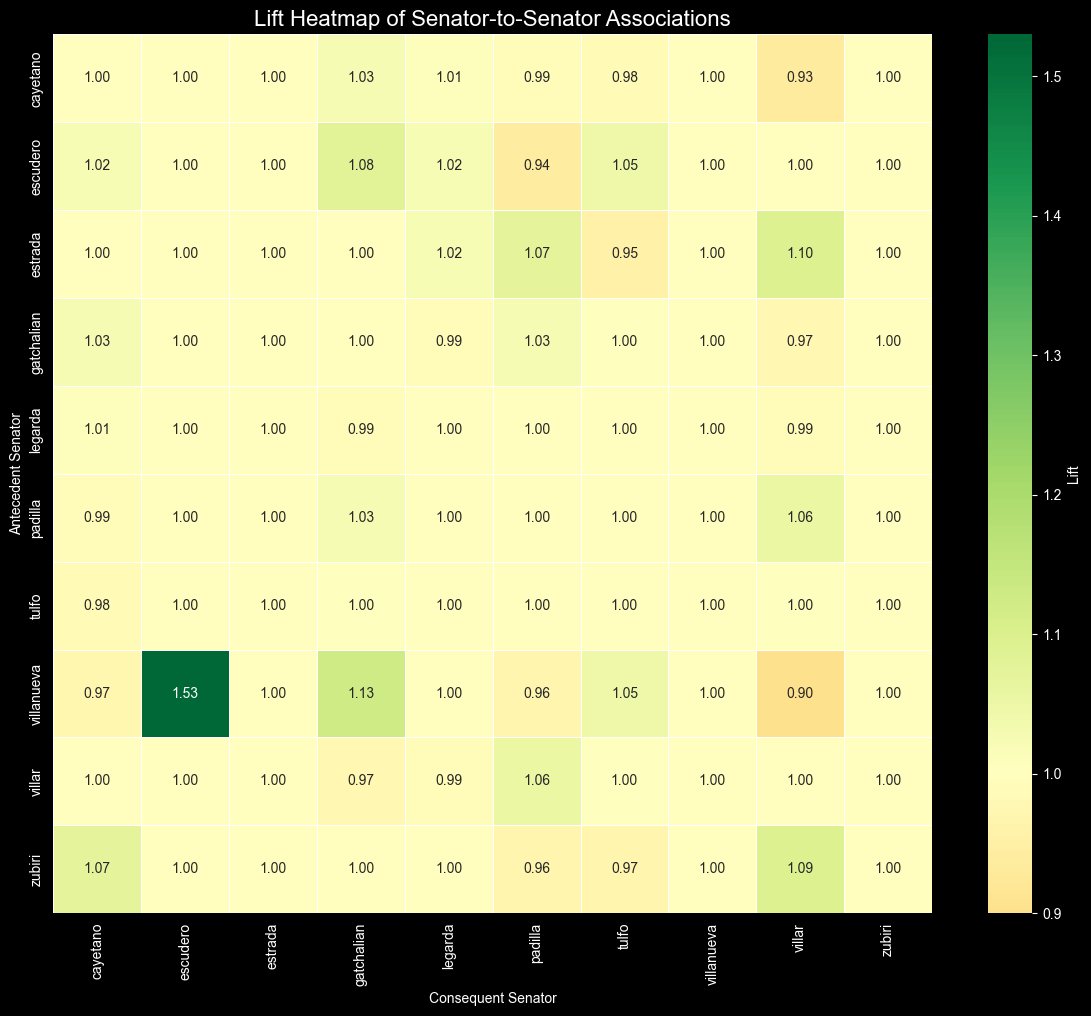

In [248]:
plt.figure(figsize=(12, 10))
sns.heatmap(lift_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Lift'})
plt.title('Lift Heatmap of Senator-to-Senator Associations', fontsize=16)
plt.xlabel('Consequent Senator')
plt.ylabel('Antecedent Senator')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

_**T4.4 - From the heatmap, identify: (a) one pair with the strongest positive association (lift >> 1), and (b) one pair with a weak or negative association (lift ≈ 1 or < 1).**_

In [249]:
max_lift = 1.0
max_pair = None
min_lift = 1.0
min_pair = None
for i in items:
    for j in items:
        if i != j:
            val = lift_matrix.loc[i, j]
            if val > max_lift:
                max_lift = val
                max_pair = (i, j)
            if val < min_lift:
                min_lift = val
                min_pair = (i, j)

In [250]:
print(f"1.) Strongest positive association (highest lift): {max_pair} -> lift = {max_lift:.3f}")
print(f"2.) Weakest/negative association (lowest lift): {min_pair} -> lift = {min_lift:.3f}")

1.) Strongest positive association (highest lift): ('villanueva', 'escudero') -> lift = 1.530
2.) Weakest/negative association (lowest lift): ('villanueva', 'villar') -> lift = 0.900


**5. Interpretation Reflect on what the Association Rules reveal about PH Voting Behavior**
-

---
**List your top 3 rules by lift in a markdown table:**
| Antecedent | Consequent | Support | Confidence | Lift  |
| :--- | :--- | :--- | :--- | :--- |
| villanueva | escudero, gatchalian | 0.333 | 0.750 | 1.607 |
| escudero, gatchalian | villanueva | 0.333 | 0.714 | 1.607 |
| legarda, villanueva | escudero | 0.378 | 0.872 | 1.569 |
---
**Analysis of Voting Bloc Patterns:**
* The association rules and heatmap reveal a clear "incumbent/veteran" voting bloc, where candidates like Legarda, Escudero, Villanueva, and Gatchalian are frequently voted for as a group. This pattern suggests that a significant portion of the electorate across various provinces preferred established names who were perceived as experienced or independent of the main administration vs. opposition rivalry. These associations align partially with the UniTeam coalition's success, as many of these candidates were either part of the slate or adopted by it, while the distinct lack of strong associations with known opposition candidates in the top rules suggests the opposition "Pink" movement had a more fragmented or localized support base compared to the broad provincial consensus found for these veteran senators.
---
**Analysis Limitations:**
* One limitation of using province-level aggregation is the loss of granularity, as it treats an entire province as a single transaction regardless of internal diversity. Provinces often contain distinct urban and rural areas or varying ethnic enclaves that might have different voting preferences. If municipality-level transactions were used instead, the results would likely show more specific regional "strongholds" and reveal narrower, more nuanced voting blocs (e.g., specific religious or local political machinery influences) that are currently smoothed out by the provincial average.
---

**6. References and AI Used in the Assessment**
-

---
* Gemini. (2025b). Gemini. https://gemini.google.com/
* DeepSeek. (2025). DeepSeek. Deepseek.com. https://chat.deepseek.com/
---